<a href="https://colab.research.google.com/github/stephenfrein/vucsc8491/blob/main/Week3_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensionality Reduction

The **Curse of Dimensionality** refers to problems that come from having too many "dimensions" (think variables or columns) in your data.

In brief, those are:

* it's harder for data mining algorithms to find the "signal" (vs random noise) in your data
* algorithms that rely on similarity and difference perform poorly because data points become very sparse (far apart)
* it's resource-intensive to handle all of the variables computationally

What is "too many" dimensions?  A loose rule of thumb says you should have at least 5 examples (rows) for every column (dimension) in your data set.

# Random Noise Can Degrade Model Performance

Simplest template for building and testing models:

1.   Get some data
2.   Break it randomly into two sets: some used for training and the rest used for tesing
3.   Build a model based on the training data only
4.   See how well its predictions correspond to the testing data that it has never seen before

The performance on the previously unseen testing data gives us an idea of how well the model matches the patterns in the world we want it to capture.



# Linear Regression Refresher

Linear regression draws a "line of best fit" through a cloud of data. It's a simple kind of model.

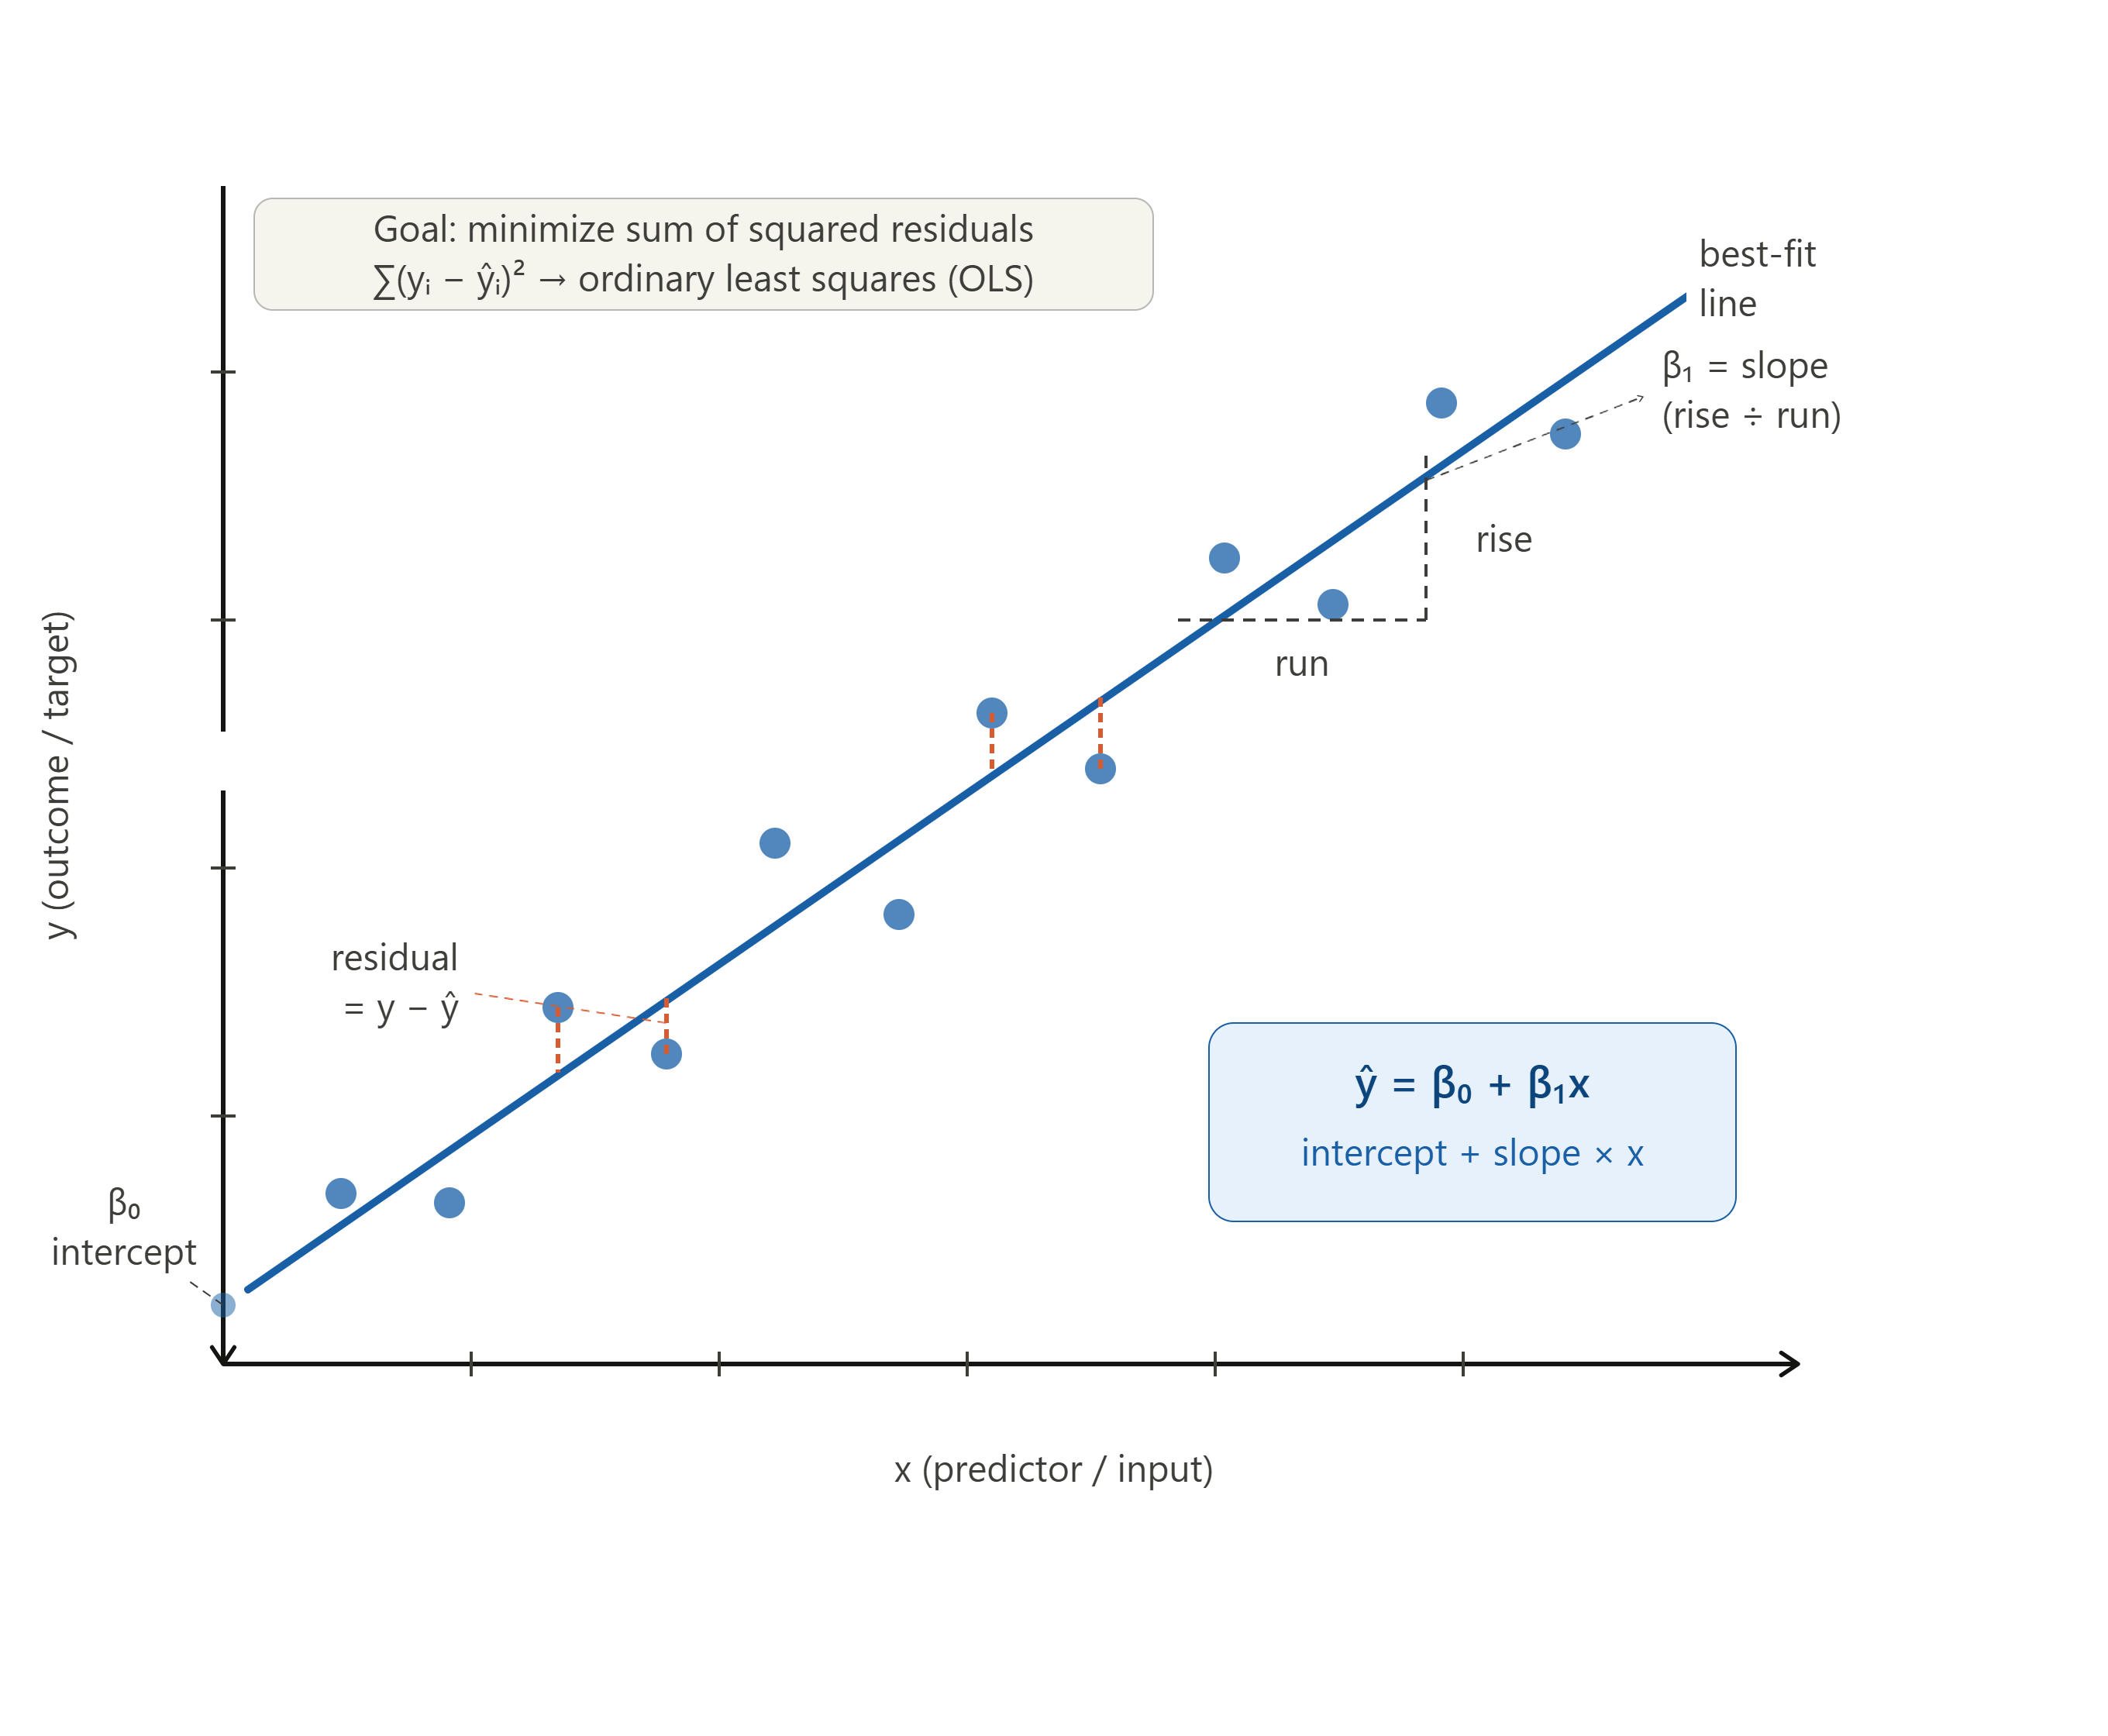

In [2]:
## let's see impact of "noise" variables in linear regression ##
## look for the big picture here - we'll revisit linear regression later

import numpy as np
# sklearn is scikit-learn - we'll be using it to build ML models
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# set a random seed value for numpy - this makes our results repeatable
np.random.seed(123)
# number of test data points we'll create
n = 200

# create 200 (n) random numbers uniformly distributed between 0 and 10
# these will be our x values
x = np.random.uniform(0, 10, n)
# print first 5 values
print(x[:5])

# create corresponding y values using y = 3x + 5 as our formula
# add a little random noise to each y to simulate real data
# the random noise values have mean zero and standard deviation of 1
y = 3 * x + 5 + np.random.normal(0, 1, n)
# print first 5 values
print(y[:5])

# notice that the operation to create y is VECTORIZED
# because x is a numpy array (1-dimensional array of same type)
# it knew to multiply 3 by every item in x and then add the noise appropriately

[6.96469186 2.86139335 2.26851454 5.51314769 7.1946897 ]
[25.15326179 13.65708729 12.20862957 23.01137244 26.89145331]


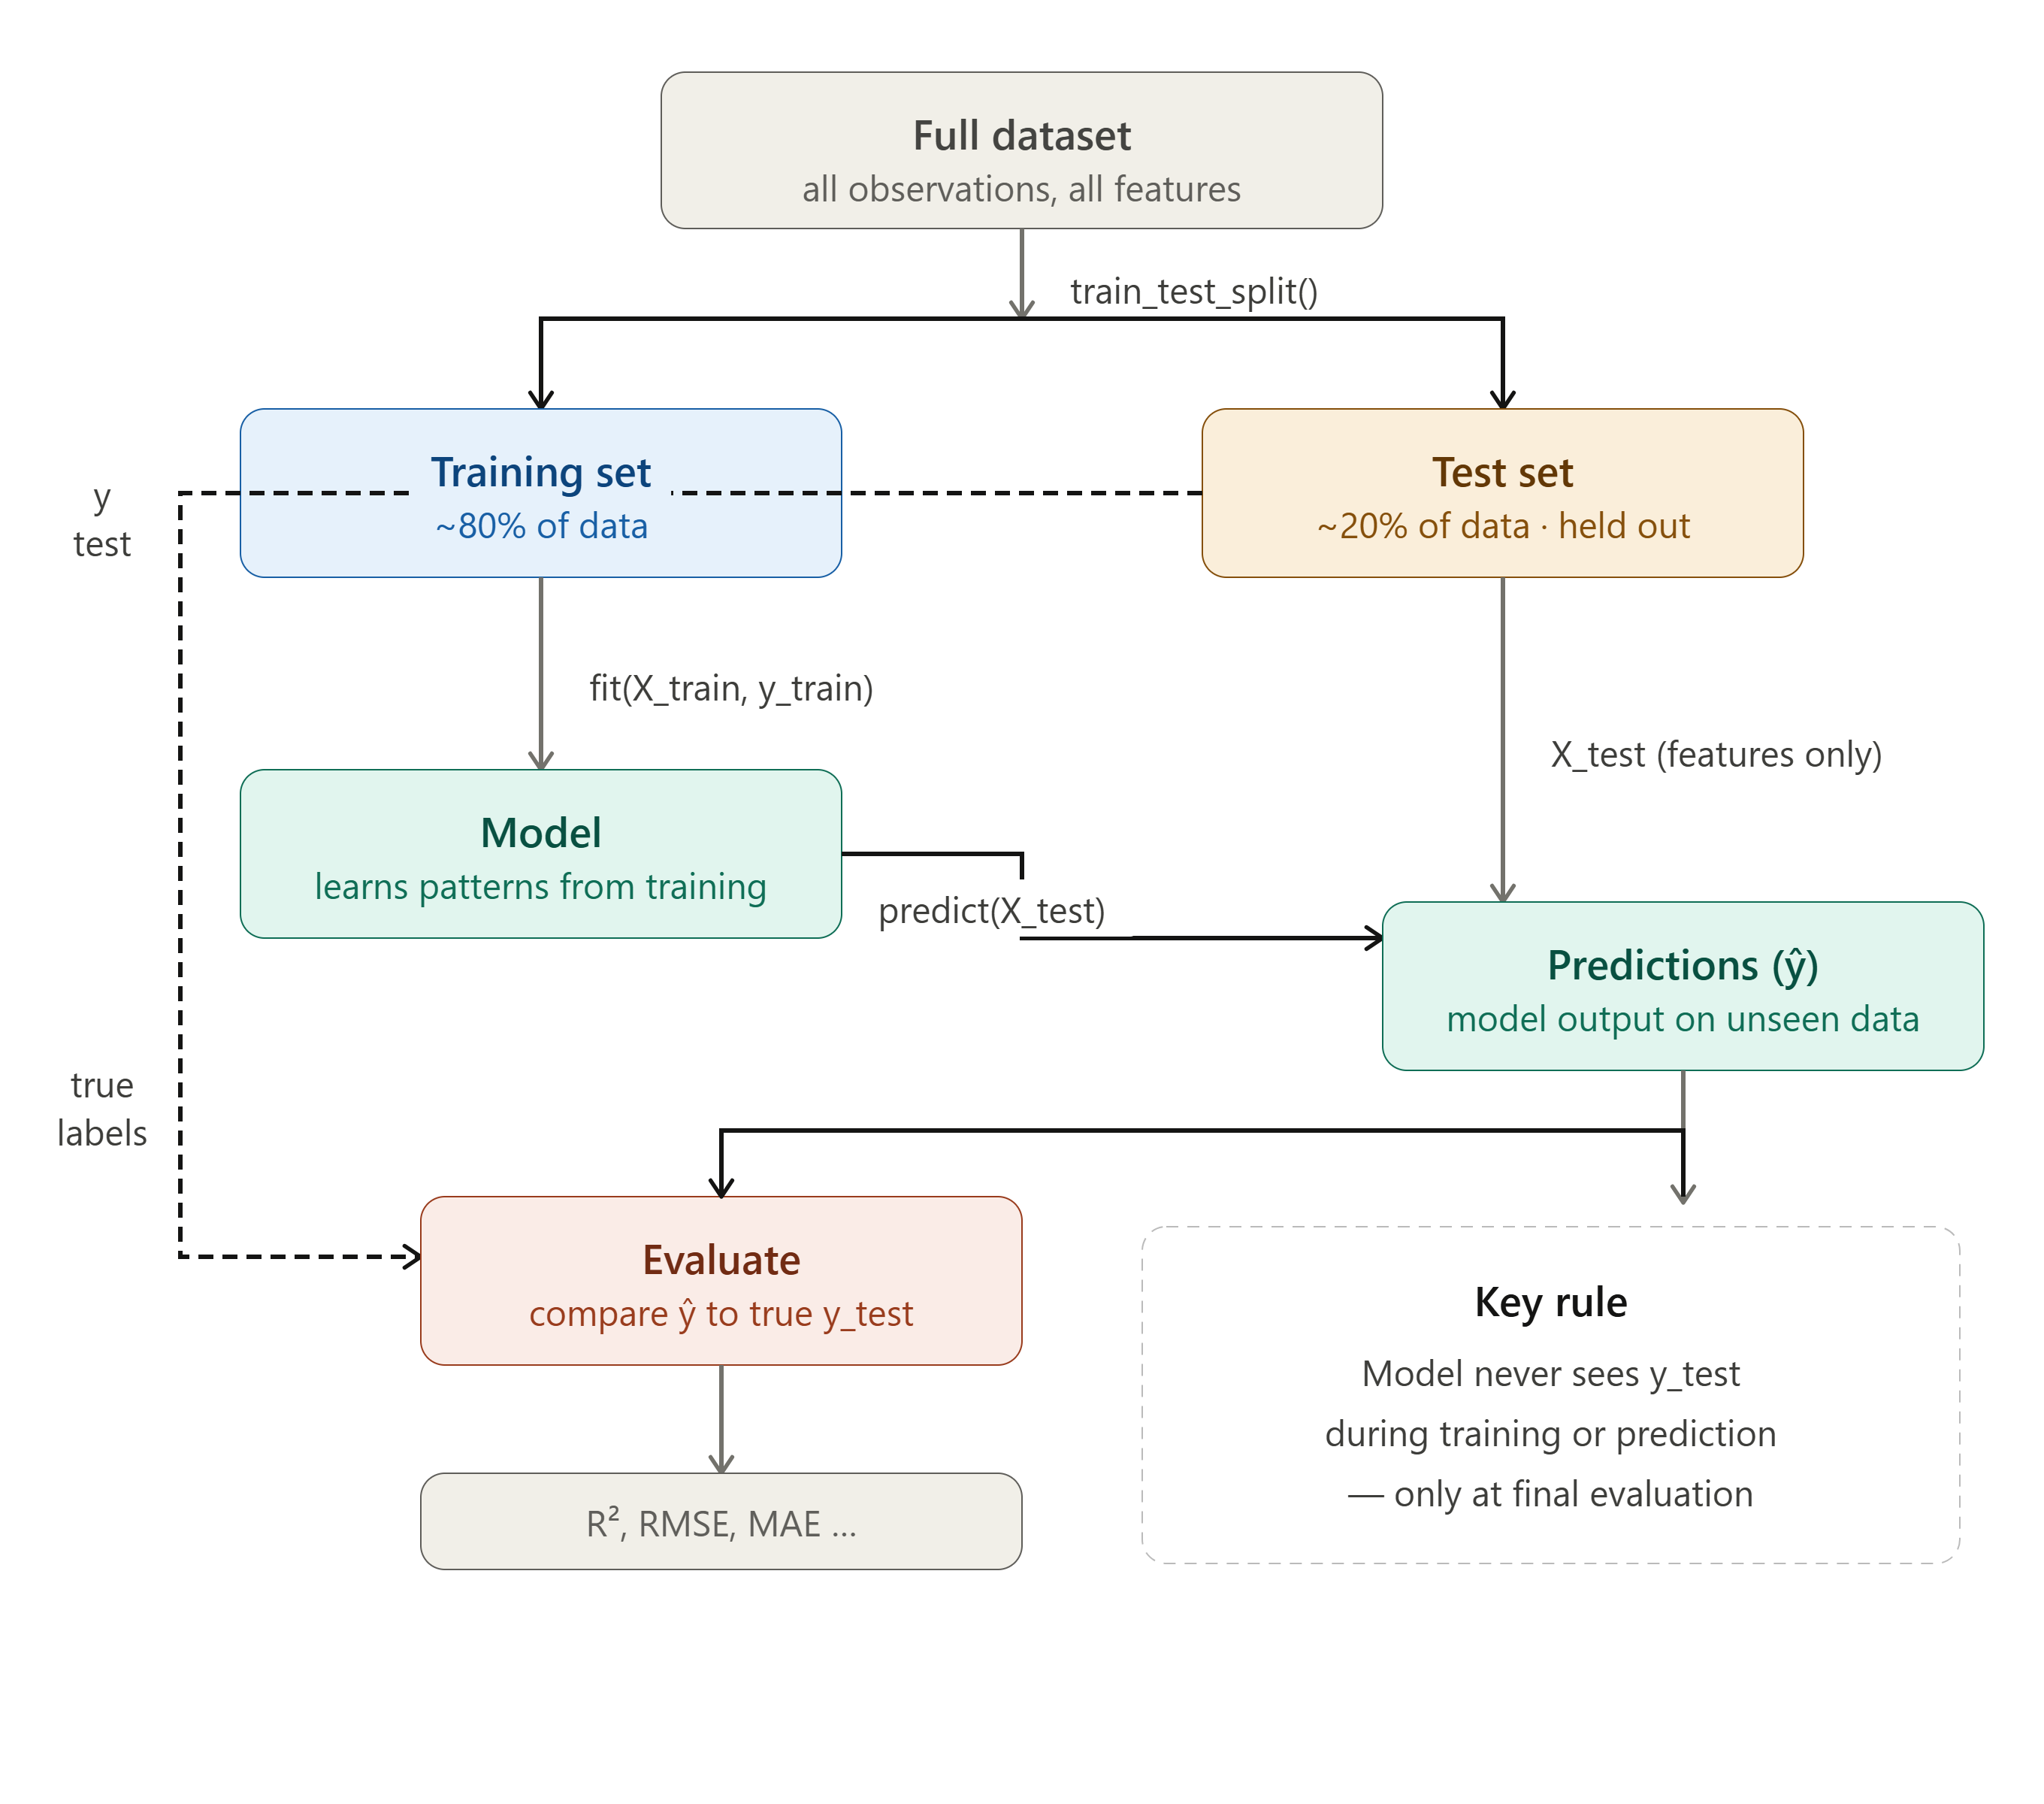

In [5]:
# create "training" and "test" groups of x and y
# we use capital X rather than lowercase x because we usually have many predictor variables
# and it is common to refer to matrixes (table-like structures) with capital letters
# 20% of the data will be used for testing
# random_state makes results repeatable
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

# now, we build a linear regression model on our training data
lr = LinearRegression()
# fit to the training data
lr.fit(X_train.reshape(-1, 1), y_train)

# see how well the same model predicts the test data
# r-squared score tells us how much variation in target variable (y)
# is explained by the predictor variable(s) - X_test in this case
r2_clean = r2_score(y_test, lr.predict(X_test.reshape(-1, 1)))
print('R-squared score on clean data is '+str(r2_clean))

R2 score on clean data is 0.9825770593426767


In [8]:
# create 100 noise variables (random, unrelated to y)
# the variables each have mean zero and standard deviation of 1
# we're asking for n rows and 100 different columns
noise = np.random.normal(0, 1, (n, 100))

# now combine the noisy, nonsense variables with our original x
X_noisy = np.column_stack([x, noise])

# create training and test data sets like before (using the noisy data)
X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.2, random_state=123)

# fit a model on the noisy training data
lr.fit(X_train, y_train)

# see how well the noisy data model predicts the test data
r2_noisy = r2_score(y_test, lr.predict(X_test))
print('R-squared score on noisy data is '+str(r2_noisy))
print('Noisy data model is only ' + str(r2_noisy/r2_clean * 100) + '% as effective as clean data model')

R-squared score on noisy data is 0.9556687184145914
Noisy data model is only 97.26145235406916% as effective as clean data model


## Increasing Dimensions Obscure "Near" and "Far"

In week 4, we'll look at clustering algorithms that rely on the idea of distace - which data points are "close" to each other (similar) and which are "far" away (dissimilar).

Increasing numbers of dimensions tend to make a point similarly "far" from all of its neighbors.

In [15]:
import numpy as np
import pandas as pd

# set seed for reproducibility
np.random.seed(123)
# how many data points (rows)?
n_points = 100
# how many different dimensions (columns) per data point?
# we'll loop though many different possibilities
# each will result in a "table" with n_points rows and dimensions columns
dimensions = [2, 10, 50, 100, 500, 1000]

# print column headers in a formatted string (an "f-string")
# things like :>6 are formatting instructions - "right justify and pad 6 chars wide"
print(f"{'Dims':>6}  {'Min dist':>9}  {'Max dist':>9}  {'Min/Max':>8}  {'Std/Mean':>9}")
# prints 50 dashes as a separator
print("-" * 50)

# loop though all the dimension (# of columns) possibilities
for dims in dimensions:
    # create random data with that many dimensions (columns) and n_points rows
    data = np.random.uniform(0, 1, (n_points, dims))

    # used to store the distances between points
    distances = []
    # for each point (row)
    for i in range(n_points):
        # we'll be comparing it to all the points (rows) that come after it
        for j in range(i + 1, n_points):
            # capture all of the values in rows i and j
            point_i = data[i]
            point_j = data[j]

            # subtract each column one at a time
            differences = [] # this is a list
            # for each column in the data
            for k in range(len(point_i)):
                # find difference in value between the two rows
                differences.append(point_i[k] - point_j[k])

            # at this point, differences contains the results of substracting all
            # the values in one row from the corresponding values in the other row
            # square each difference
            squared_differences = []
            for diff in differences:
                squared_differences.append(diff ** 2)

            # add up all those squared differences
            sum_of_squares = 0
            for sq in squared_differences:
                sum_of_squares += sq

            # take the square root to get "straight-line" distance
            # this is Pythagorean theorem being extended to more than 2D
            d = np.sqrt(sum_of_squares)
            # each time this line runs, we're saving the distance between 2 rows
            distances.append(d)

    # once we get here, distances contains all the distances between all the
    # rows for the current number of dimensions (columns)

    # convert to numpy array just to make upcoming calcs easy (built-in methods)
    distances = np.array(distances)

    # how close are the two closest (most similar rows)
    min_d = distances.min()
    # how close are the two farthest (most dissimilar rows)
    max_d = distances.max()
    # ratio of those two distances
    ratio = min_d / max_d
    # ratio of the spread of differences to the average of distances
    cv = distances.std() / distances.mean()

    # print out those calcs for each number of dimensions
    print(f"{dims:>6}  {min_d:>9.3f}  {max_d:>9.3f}  {ratio:>8.3f}  {cv:>9.3f}")

print()
print("Min/Max → 1.0 means nearest and farthest neighbours are nearly equidistant.")
print("Std/Mean → 0.0 means all distances are mostly same — 'near' loses its meaning.")

  Dims   Min dist   Max dist   Min/Max   Std/Mean
--------------------------------------------------
     2      0.014      1.337     0.010      0.479
    10      0.422      2.143     0.197      0.194
    50      2.055      3.742     0.549      0.084
   100      3.194      4.909     0.651      0.058
   500      8.190     10.099     0.811      0.026
  1000     12.125     13.719     0.884      0.018

Min/Max → 1.0 means nearest and farthest neighbours are nearly equidistant.
Std/Mean → 0.0 means all distances are the same — 'near' loses its meaning.


In [31]:
# show visually that same distance over greater dimensions
# leads to sparser data

# don't worry about all the plotting logic - just absorb the sparsity idea

import plotly.graph_objects as go
import math

# define data points
# the red points differ by 2 on 2 dimensions (x and y)
red_p1, red_p2 = [2, 2, 1], [4, 4, 1]
# the blue points differ by 2 on 3 dimensions (x and y and z)
blue_p1, blue_p2 = [5, 5, 5], [7, 7, 7]

# calculate lengths between the two reds and the two blues
red_len = math.dist(red_p1, red_p2)
blue_len = math.dist(blue_p1, blue_p2)

# calculate midpoints for placing the labels
red_mid = [(red_p1[i] + red_p2[i]) / 2 for i in range(3)]
blue_mid = [(blue_p1[i] + blue_p2[i]) / 2 for i in range(3)]

# define the 3D plot
fig = go.Figure(data=[
    # plot red line (2 dimensions differ by 2 each)
    go.Scatter3d(
        x=[red_p1[0], red_p2[0]], y=[red_p1[1], red_p2[1]], z=[red_p1[2], red_p2[2]],
        mode='lines+markers',
        line=dict(color='red', width=5), marker=dict(size=8, color='red')
    ),
    # red line add label (invisible point, text only)
    go.Scatter3d(
        x=[red_mid[0]], y=[red_mid[1]], z=[red_mid[2]],
        mode='text', text=[f'Len: {red_len:.2f}'],
        textposition='top center', textfont=dict(color='red')
    ),

    # plot blue line (3 dimensions differ by 2 each)
    go.Scatter3d(
        x=[blue_p1[0], blue_p2[0]], y=[blue_p1[1], blue_p2[1]], z=[blue_p1[2], blue_p2[2]],
        mode='lines+markers',
        line=dict(color='blue', width=5), marker=dict(size=8, color='blue')
    ),
    # Blue Line Label Trace
    go.Scatter3d(
        x=[blue_mid[0]], y=[blue_mid[1]], z=[blue_mid[2]],
        mode='text', text=[f'Len: {blue_len:.2f}'],
        textposition='top center', textfont=dict(color='blue')
    )
])

# Update layout
fig.update_layout(
    showlegend=False,
    scene=dict(
        xaxis=dict(title='X Axis', range=[0, 8]),
        yaxis=dict(title='Y Axis', range=[0, 8]),
        zaxis=dict(title='Z Axis', range=[0, 8])
    ),
    title="3D Lines with Length Labels",
    margin=dict(l=0, r=0, b=0, t=40)
)

# Display the interactive plot
fig.show()